- Valentina Acevedo Mesa - CC1000763409
- Juan José Garcés Rojas - CC1007409305

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import welch as pwelch
from scipy.io import loadmat
from scipy.signal import welch, windows

Se tienen los siguientes datos para realizar el análisis de la señal: frecuencia fundamental de la señal, amplitud, frecuencia y periodo de muestreo.

En el primer caso, el periodo de la señal analógico o tiempo continuo es de 0,025seg

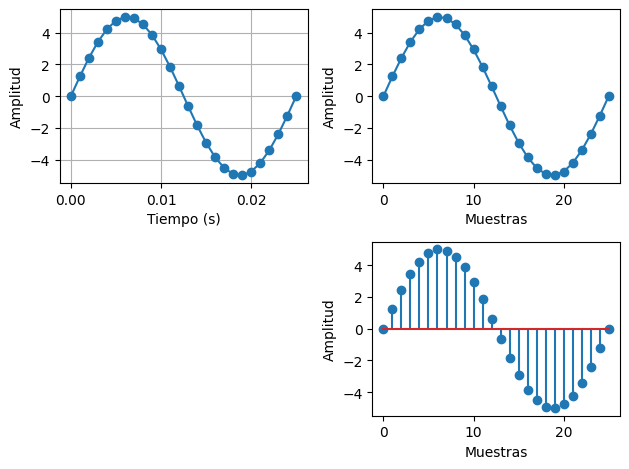

In [82]:
Fo= 40
A= 5
T = 1/Fo #Periodo de la señal
Fs= 1000
Ts= 1/Fs #Periodo de muestreo

t= np.arange(0, T+Ts, Ts)
x= A*np.sin(2*np.pi*Fo*t)  #Brinda información de lo que sucede de forma analógica

fo= Fo/Fs
n= np.arange(0, len(t))
xN= A*np.sin(2*np.pi*fo*n)

plt.subplot(2,2,1)
plt.plot(t,x, marker='o')
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.subplot(2,2,2)
plt.plot(n,xN,marker='o')
plt.xlabel("Muestras")
plt.ylabel("Amplitud")

plt.subplot(2,2,4)
plt.stem(n, xN) #Grafica de la señal muestreada con stem
plt.xlabel("Muestras")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

# Comprobar que los valores de las primeras 5 muestras son los mismos

In [83]:
tabla = pd.DataFrame({
    "Muestra n": n[:5],
    "Tiempo t (s)": t[:5],
    "x(t)": x[:5],
    "xN(n)": xN[:5],
    "Diferencia": x[:5] - xN[:5]
})

tabla

,Muestra n,Tiempo t (s),x(t),xN(n),Diferencia
0,0,0.000,0.000000,0.000000,0.0
1,1,0.001,1.243449,1.243449,0.0
2,2,0.002,2.408768,2.408768,0.0
3,3,0.003,3.422736,3.422736,0.0
4,4,0.004,4.221640,4.221640,0.0


## a)	Compruebe que los valores de las primeras cinco muestras son los mismos
Se comprobó que las primeras cinco muestras de ambas señales son iguales, ya que para cada valor de n la diferencia entre x(t) y xN(n) es cero. Esto ocurre porque ambas expresiones representan la misma señal sinusoidal, solo que una está escrita en función del tiempo t y la otra en función del número de muestra n.

### Energía de potencia en el dominio del tiempo
- Energía: $V^2$ o W
- Potencia: ${energía}/{(len(t)-1)}$
- RMS: $\sqrt{potencia}$

Se consideran 10 ciclos de la sinusoide (250ms)



In [84]:
energia= sum(x**2)
potencia = energia/(len(t)-1)
rms= np.sqrt(potencia)

In [85]:
t10= np.arange(0, 10*T+Ts, Ts)
x10= A*np.sin(2*np.pi*Fo*t10)

energia10= sum(x10**2)
potencia10= energia10/(len(t10)-1)
rms10= np.sqrt(potencia10)

# La potencia es la misma que en x. ¿Por qué?
La potencia es la misma porque la señal de 10 ciclos tiene la misma amplitud y frecuencia que la señal de un ciclo; simplemente se repite más veces. Aunque la energía aumenta al considerar más ciclos, la potencia media se calcula dividiendo la energía entre el número de muestras evaluadas, por lo que el valor promedio de x
2
(n) se mantiene constante.

En una sinusoide periódica, la potencia media no depende de cuántos ciclos completos se analicen, siempre que se tome un número entero de periodos.

### Análisis de Fourier en tiempo discreto

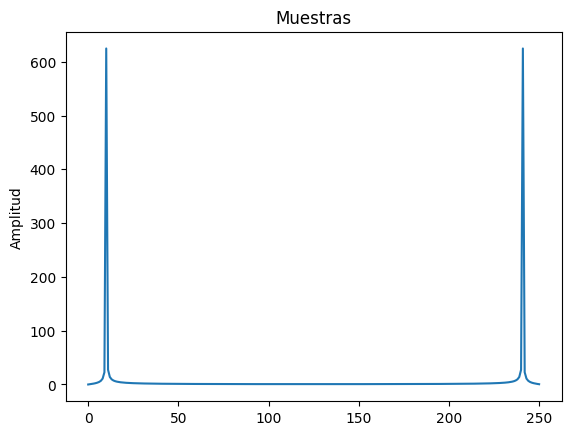

In [86]:
X10= np.fft.fft(x10)
plt.plot(abs(X10))
plt.title("Muestras")
plt.ylabel("Amplitud")
plt.show()

El valor máximo de la señal en amplitud es de 625
- X(K) está relacionada con los coeficientes $c_k$ de la serie de Fourier de la señal xp(n) que se obtiene por la repetición de x(n)
- x(n) contiene el número entero de periodos
- x(p) es la señal originada de duración finita
  - $X(K) = N*c_k$
- Cuando una sinusoide pura se representa usando la serie de Fourier, la energía se divide en 2 exponentes complejos (frecuencias positivas y negaticas) y se calculan los coeficientes:
$ |c_k|= 5*0.5 = 2.5$
- La transformada de Fourier no calcula directamente el promedio de la amplitud, sino que acumula los valores a lo largo de todas las muestras (N):
  - N * $|c_k|$ = 625 (factor de escalamiento)  
- indices que representan los 250 valores k de X(K) se deben escalar para llevarlos a valores de frecuencia por medio de $f= k/N$
- Si se van a comparar las F con tiempo continuo para conclusiones e información se utiliza: $F= (k*Fs)/N$

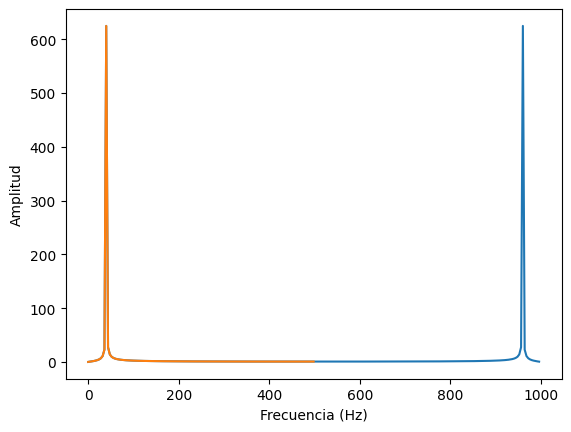

In [87]:
N= len(X10)
F= np.arange(0,N)*Fs/N
plt.plot(F,abs(X10))
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

# Se grafica la mitad de la frecuencia de muestreo por simetría. La mitad es frecuencia de Nyquist
Nmitad= int(np.ceil(N/2))
Fmitad= (np.arange(0,Nmitad)*Fs/N)
X10mitad= X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad))
plt.ylabel("Amplitud")
plt.xlabel("Frecuencia (Hz)")
plt.show()

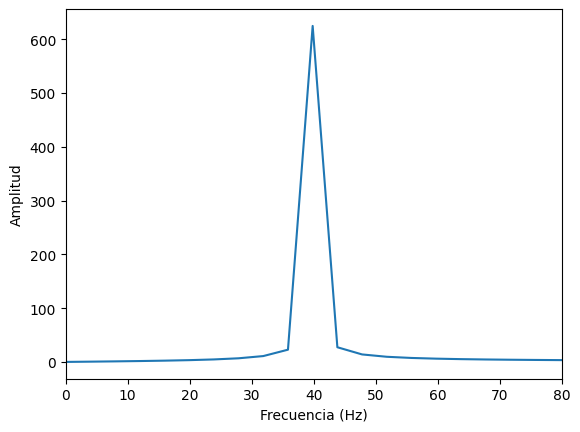

In [88]:
plt.plot(Fmitad, abs(X10mitad))
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")
plt.xlim(0,80)
plt.show()

# Periodograma
Se calcula por medio de la transformada discreta y una ventana corta centrada en un valor específico para estimar la potencia de las frecuencias en el intervalo.
- ventana rectangular: periodograma
- ventana otra forma: periodograma modificado

## Periodograma por Welch
análisis de una señal de larga duración sin usar ventanas cortas. Calcula la densidad espectral de potencia en una ventana que se desplaza a lo largo de la señal y promedia los espectros de potencia.

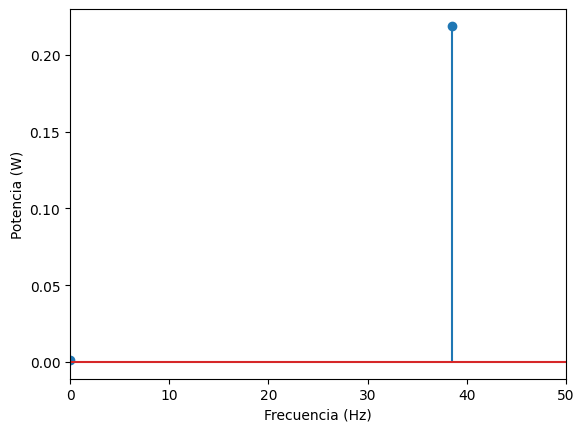

In [89]:
nperseg= len(x) # Ancho de la ventana, ajustado a la longitud de la señal
noverlap= int(nperseg/2) # Solapamiento de las ventanas
f, Pxx= pwelch(x, Fs, 'hann', nperseg, noverlap)

# Gráfica de frecuencia vs potencia
plt.stem(f,Pxx)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia (W)")
plt.xlim([0,50])
plt.show()

# PRÁCTICA 5

*a)* crear señal que sea la suma de 3 componentes sinusidales con frecuencia de 40, 80 y 160Hz. Definir la frecuencia de muestreo necesaria para representarla.

Teniendo en cuenta que la mayor frecuencia que presenta la señal es la de 160Hz, por el teorema de Nyquist que indica que la frecuencia de meustreo debe ser mayor a 2 veces la frecuencia máxima de la señal completa y si es mayor a 2 veces la frecuencia máxima, se obtiene una mejor resolución de la señal.
$$ f_s > 2f_{max} $$
$$ f_s > 2(160_{Hz}) = 320 $$
$$ f_s = 1600$$
Para conocer el periodo de la señal, se toma en cuenta la frecuencia más baja de la señal que corresponde a 40Hz que también se calcula teniendo en cuenta la frecuencia de muestreo:
$$ T= 1/40 = 0,025seg$$
La duración total de la señal para 10 ciclos de la frecuencia más baja es de $T_{tot}= 10*T = 0.25seg$

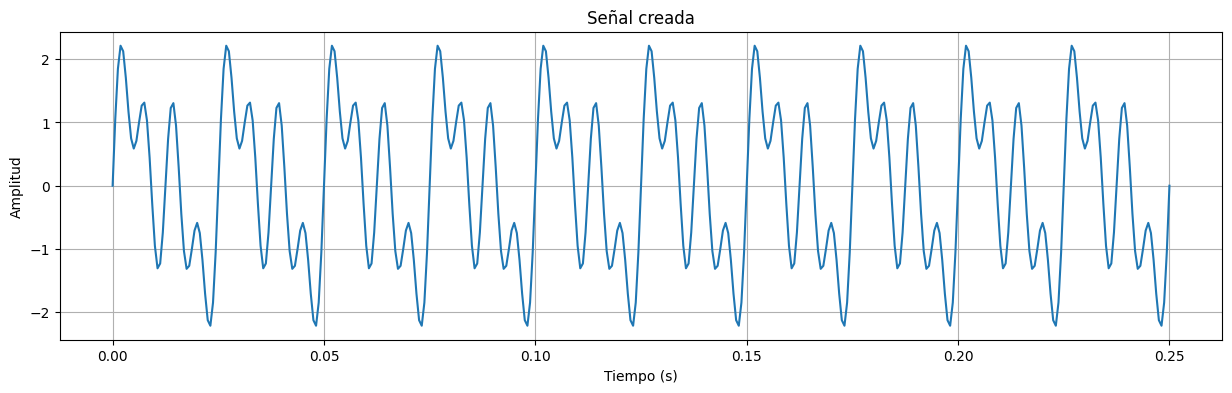

In [90]:
fs= 1600
Ts= 1/fs
T= 0.25
t= np.arange(0, T+Ts, Ts)

senal= np.sin(2*np.pi*40*t)+np.sin(2*np.pi*80*t)+np.sin(2*np.pi*160*t)

plt.figure(figsize=(15,4))
plt.plot(t, senal)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal creada")
plt.grid()
plt.show()

*b)* Calcular la transformada de Fourier de la señal y graficar el espectro de frecuencia. Identififcar las frecuencias que componen la señal.

Teniendo en cuenta la simetría de la señal, solo se trabajará con la mitad de los datos

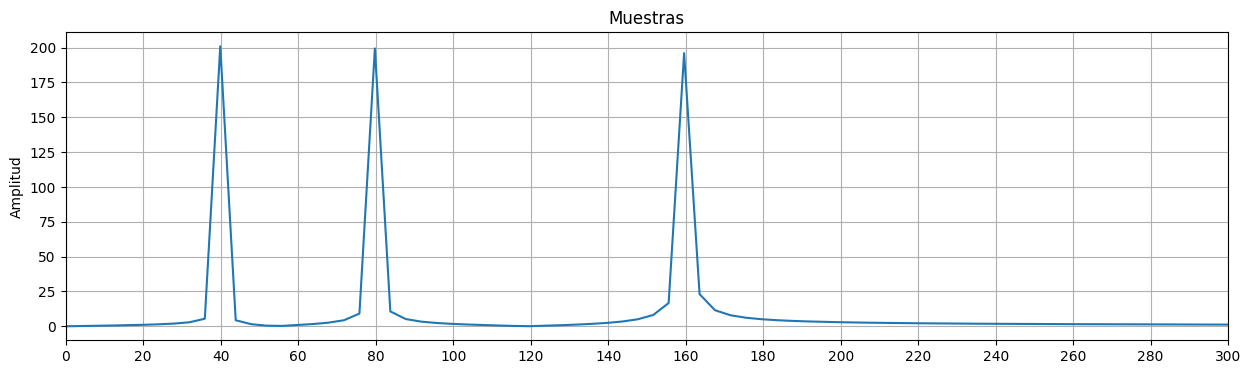

Picos espectrales principales:
Frecuencia: 40.0 Hz  ->  Magnitud: 200.96
Frecuencia: 80.0 Hz  ->  Magnitud: 199.40
Frecuencia: 156.0 Hz  ->  Magnitud: 16.68
Frecuencia: 160.0 Hz  ->  Magnitud: 196.01
Frecuencia: 164.0 Hz  ->  Magnitud: 23.09


In [91]:
t10= np.arange(0, 10*T+Ts, Ts)
x10= np.sin(2*np.pi*40*t)+np.sin(2*np.pi*80*t)+np.sin(2*np.pi*160*t)
freqs = np.arange(0, 400) * fs / 400    # Vector de frecuencias

X10= np.fft.fft(x10)
N= len(X10)
Nmitad= int(np.ceil(N/2))
Fmitad= (np.arange(0,Nmitad)*fs/N)
X10mitad= X10[0:Nmitad]

plt.figure(figsize=(15,4))
plt.plot(Fmitad, abs(X10mitad))
plt.title("Muestras")
plt.ylabel("Amplitud")
plt.xlim(0,250)
plt.grid()
plt.xticks(np.arange(0, 301, 20))
plt.show()

# Imprimir picos principales
print("Picos espectrales principales:")
indices = np.argsort(abs(X10[:N//2]))[-5:]  # buscar picos más altos en mitad positiva
for idx in sorted(indices):
    print(f"Frecuencia: {freqs[idx]:.1f} Hz  ->  Magnitud: {abs(X10[idx]):.2f}")

**c) Tranformada inversa de Fourier**
permite reconstruir una señal en el dominio del tiempo partiendo del dominio de la frecuencia. Matemáticamente se define como:
$$ x[n]= 1/N ∑X[k]*e^{j2kn\pi/N} $$

Para implementar en python la transformada inverda de Fourier se hace usi de la librería numy con la función $$np.fft.ifft(a, n=None, axis=-1, norm=None, out=None)$$
  - a= array_like (contiene los coeficientes en el dominio de la frecuencia real o complejo)
  - n= número de puntos de la transformada inversa
    - si n es menor que la longitud de a, se recorta
    - si n es mayor, se rellena de ceros
    - si no se especifica, se usa la misma longitud de a
  - axis= el eje sobre el cual se calcula la transformada inversa (por defecto se usa el último eje)
  - nomr= define el modo de la normalización
    - "backward": por defecto, escala de la transformada inversa
    - "forward": escala de la transformada directa
    - "ortho": normalización ortogonal
  
Referencia: https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html y https://www.mycompiler.io/view/5gBWEiQPDS6

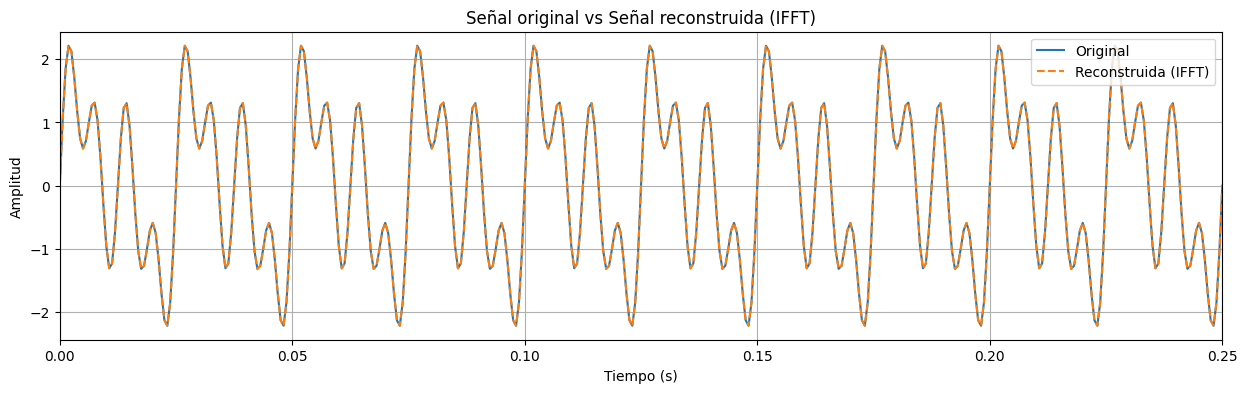

In [92]:
Xrecuperada= np.fft.ifft(X10)

plt.figure(figsize=(15,4))
plt.plot(t, senal, label="Original")
plt.plot(t, Xrecuperada.real, '--', label="Reconstruida (IFFT)")
plt.xlim(0, 0.25)
plt.title("Señal original vs Señal reconstruida (IFFT)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()


**d) Aplicación de un filtro?**

Las líneas de código si realizan el filtrado de la señal original ya que selecciona un rango de frecuencias y "elimina" las demás. Este tipo de filtrado se conoce como filtro pasa bandas.

/tmp/ipykernel_9024/3791264439.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13]; #Se utilizan solo los coeficientes de frecuencia que están en un rango específico de frecuencia (filtro)


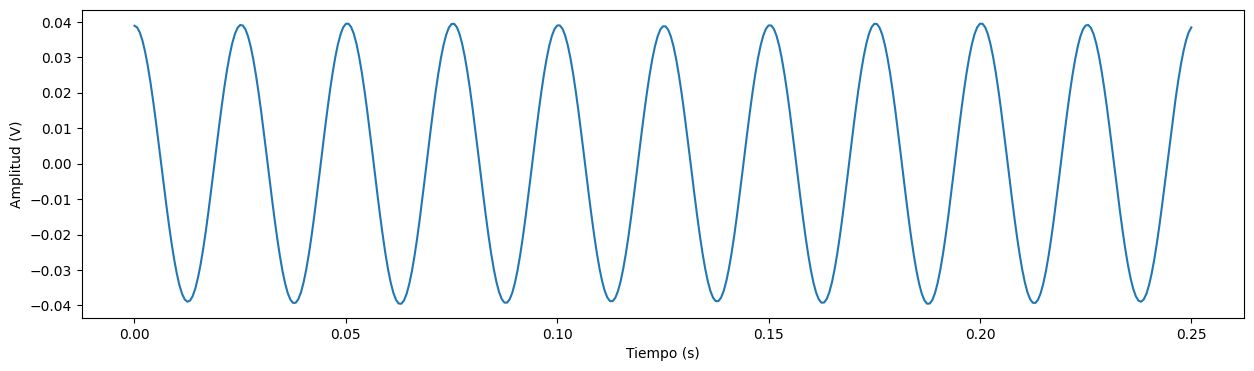

In [93]:
F1 = np.fft.fft(senal); # Calcula la FFT de la señal original
F2 = np.zeros((len(F1))); # Se crea un arreglo de ceros del mismo tamaño de la FFT
F2[9:13] = F1[9:13]; #Se utilizan solo los coeficientes de frecuencia que están en un rango específico de frecuencia (filtro)

xr = np.fft.ifft(F2); # Recupera la señal en el dominio del tiempo y se verá una señal filtrada

fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');

plt.show()

Separación de las señales originales utilizando el filtro pasabandas

Ya que se quiere analizar y regresar al tiempo continuo, es necesario hacer uso de la fórmula: $F= (k*Fs)/N$ para cada señal

In [94]:
F= np.fft.fft(senal)
N = len(F)       # número de puntos de la FFT
k40 = int(40 * N / fs)   # índice para 40 Hz
k80 = int(80 * N / fs)   # índice para 80 Hz
k160 = int(160 * N / fs) # índice para 160 Hz

# Se realiza el mismo proceso de antes teniendo en cuenta los coeficientes

# Señal de 40 Hz
f1 = np.zeros_like(F)
f1[k40] = F[k40]
f1[-k40] = F1[-k40] #Espejo de la señal de 40 Hz para coger el espectro completo y no solo la mitad

# Señal de 80 Hz
f2 = np.zeros_like(F)
f2[k80] = F[k80]
f2[-k80] = F1[-k80]

# Señal de 160 Hz
f3 = np.zeros_like(F)
f3[k160] = F[k160]
f3[-k160] = F1[-k160]

x1 = np.fft.ifft(f1)
x2 = np.fft.ifft(f2)
x3 = np.fft.ifft(f3)

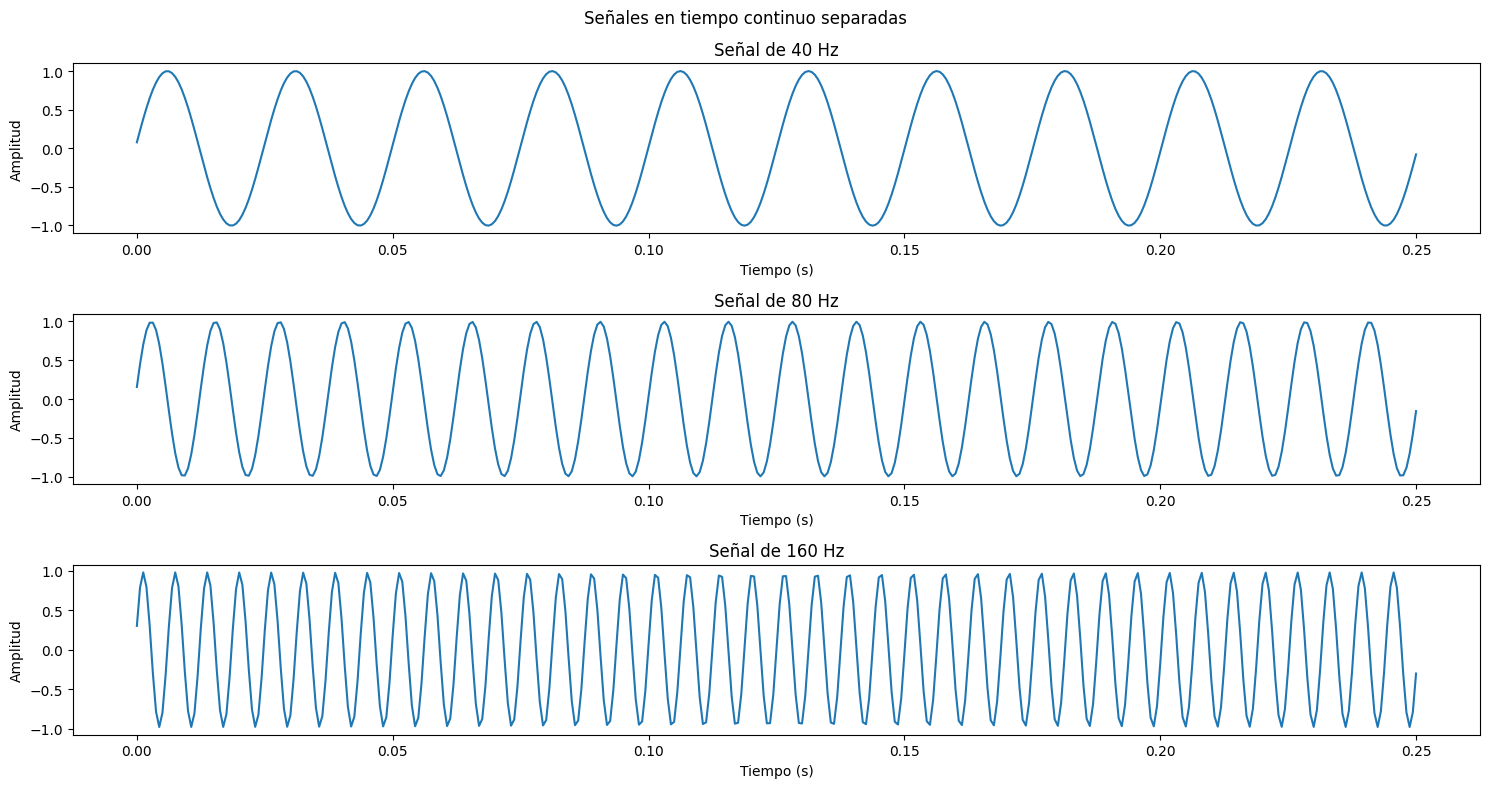

In [95]:
plt.figure(figsize=(15,8))

plt.subplot(3,1,1)
plt.plot(t, np.real(x1))
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal de 40 Hz")

plt.subplot(3,1,2)
plt.plot(t, np.real(x2))
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal de 80 Hz")

plt.subplot(3,1,3)
plt.plot(t, np.real(x3))
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal de 160 Hz")

plt.suptitle("Señales en tiempo continuo separadas")
plt.tight_layout()
plt.show()

**e) Ventana para senecg.mat**

El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)

In [96]:
# Cargar archivo .mat

datos = loadmat("senecg.mat")

# Revisar las variables internas del archivo
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'ECG'])


In [97]:
# Extraer la señal ECG

ecg = datos["ECG"].squeeze()

Fs = 250              # Frecuencia de muestreo en Hz
Ts = 1/Fs             # Periodo de muestreo
N = len(ecg)          # Número de muestras
t = np.arange(0, N)*Ts

print("Número de muestras:", N)
print("Duración de la señal:", N/Fs, "s")

Número de muestras: 1250
Duración de la señal: 5.0 s


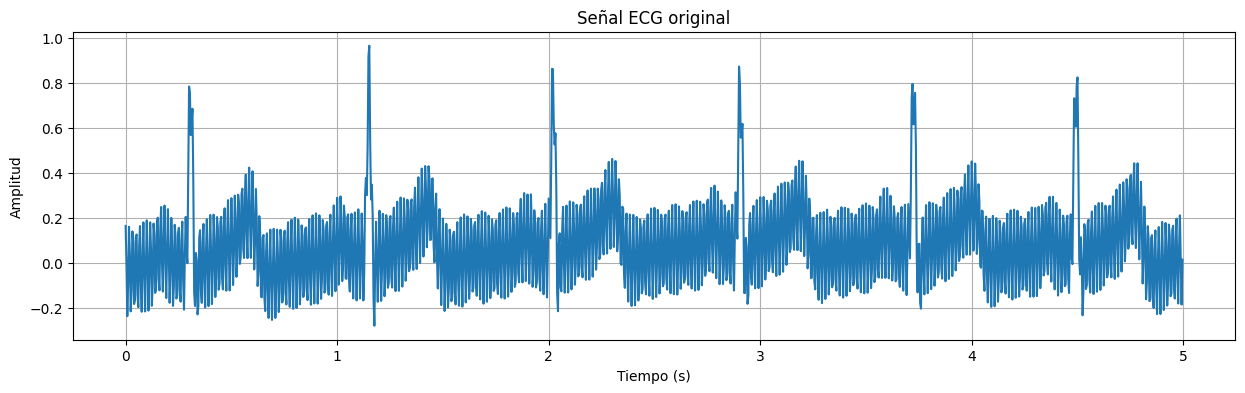

In [98]:
# Graficar la señal ECG en el dominio del tiempo

plt.figure(figsize=(15,4))
plt.plot(t, ecg)
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG original")
plt.show()

Evidentemente por la gráfica de la señal original se requiere un proceso de filtrado para eliminar todo el ruido presente en la señal

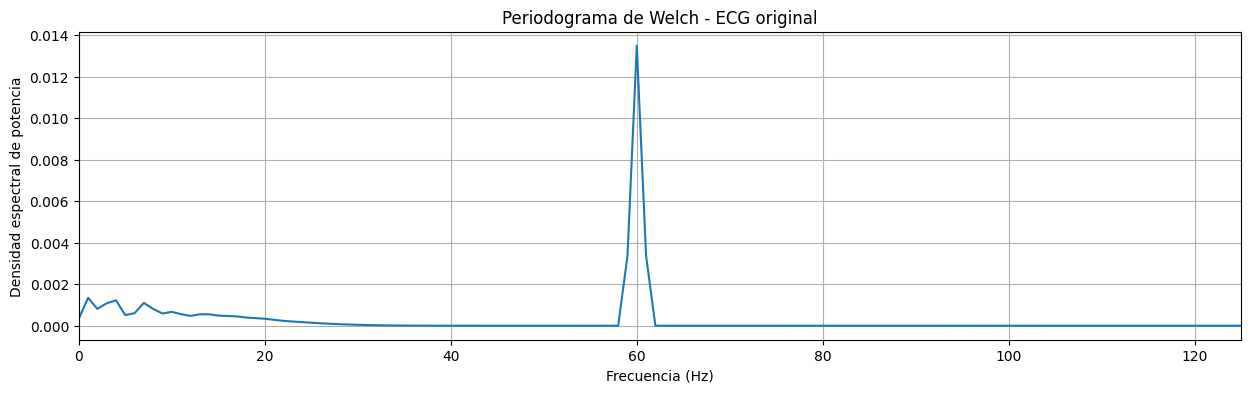

In [99]:
# Periodograma de Welch de la señal original

nperseg = 250          # Ventana de 1 segundo
noverlap = 125         # 50% de solapamiento

f, Pxx = welch(
    ecg,
    fs=Fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap
)

plt.figure(figsize=(15,4))
plt.plot(f, Pxx)
plt.grid()
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia")
plt.title("Periodograma de Welch - ECG original")
plt.xlim(0, 125)
plt.show()

Claramente por la gráfica podemos ver que la frecuencia con mayor potencia es en 60Hz, sin embargo lo ponemos en código para que todo quede debidamente documentado

In [100]:
indice_max = np.argmax(Pxx)
frecuencia_max = f[indice_max]

print("Frecuencia con mayor potencia:", frecuencia_max, "Hz")

Frecuencia con mayor potencia: 60.0 Hz


In [101]:
# Filtrado en frecuencia usando FFT
# Se elimina la componente alrededor de 60 Hz

F_ecg = np.fft.fft(ecg)
freq = np.fft.fftfreq(N, d=Ts)

F_ecg_filtrada = F_ecg.copy()

# Banda de ruido a eliminar: 59 Hz a 61 Hz
banda_ruido = (np.abs(freq) >= 59) & (np.abs(freq) <= 61)

F_ecg_filtrada[banda_ruido] = 0

In [102]:
# Transformada inversa de Fourier para reconstruir la señal filtrada

ecg_filtrada = np.fft.ifft(F_ecg_filtrada)
ecg_filtrada = np.real(ecg_filtrada)

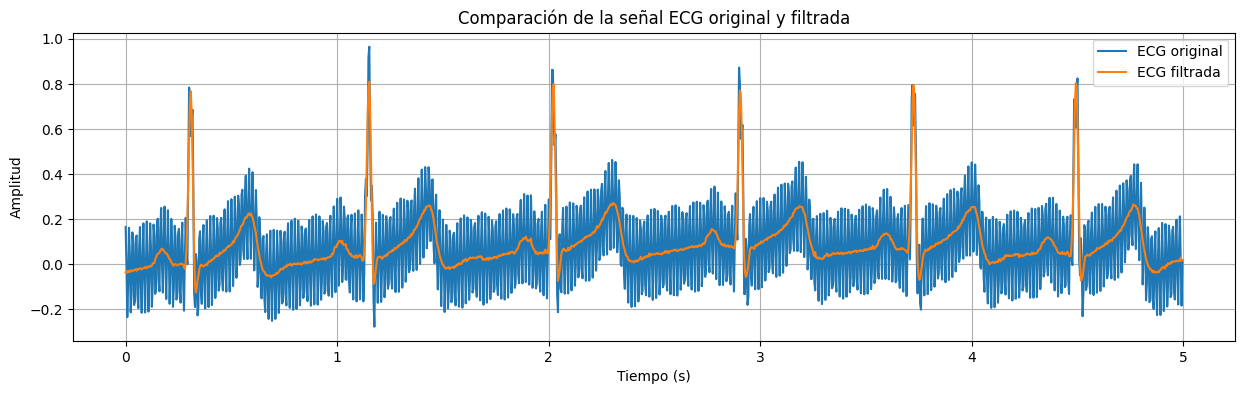

In [103]:
# Comparación en el tiempo: ECG original vs ECG filtrada

plt.figure(figsize=(15,4))
plt.plot(t, ecg, label="ECG original")
plt.plot(t, ecg_filtrada, label="ECG filtrada")
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Comparación de la señal ECG original y filtrada")
plt.legend()
plt.show()

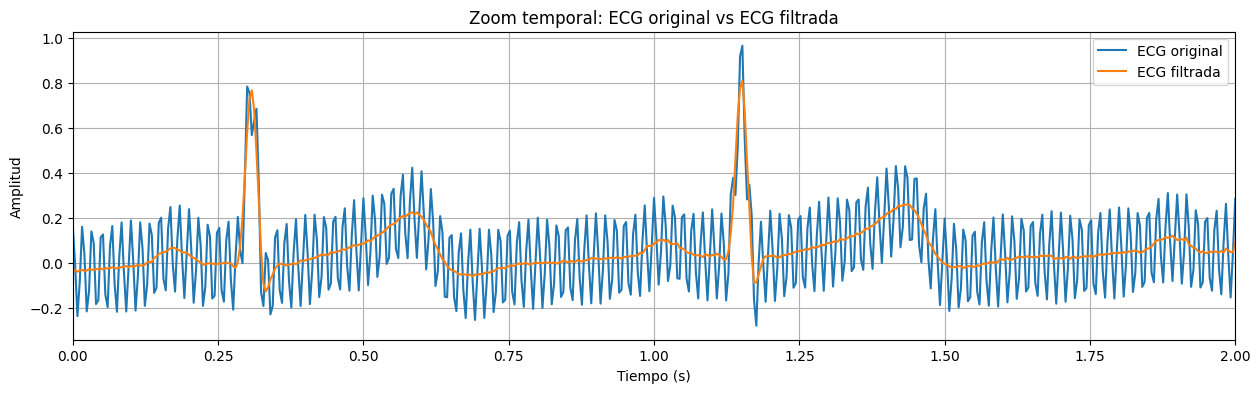

In [104]:
# Comparación con zoom en el tiempo

plt.figure(figsize=(15,4))
plt.plot(t, ecg, label="ECG original")
plt.plot(t, ecg_filtrada, label="ECG filtrada")
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Zoom temporal: ECG original vs ECG filtrada")
plt.xlim(0, 2)
plt.legend()
plt.show()

En la figura se compara la señal ECG original con la señal ECG filtrada en el dominio del tiempo. Se observa que la señal original presenta una componente de alta frecuencia superpuesta, lo que genera una apariencia más ruidosa y dificulta la visualización clara de la morfología del ECG. Después del filtrado, la señal conserva los picos principales asociados a los complejos QRS, pero presenta una forma más suavizada, indicando que se redujo una componente de ruido de alta frecuencia. Esto permite observar con mayor claridad el comportamiento general de la señal cardíaca sin eliminar sus características principales.

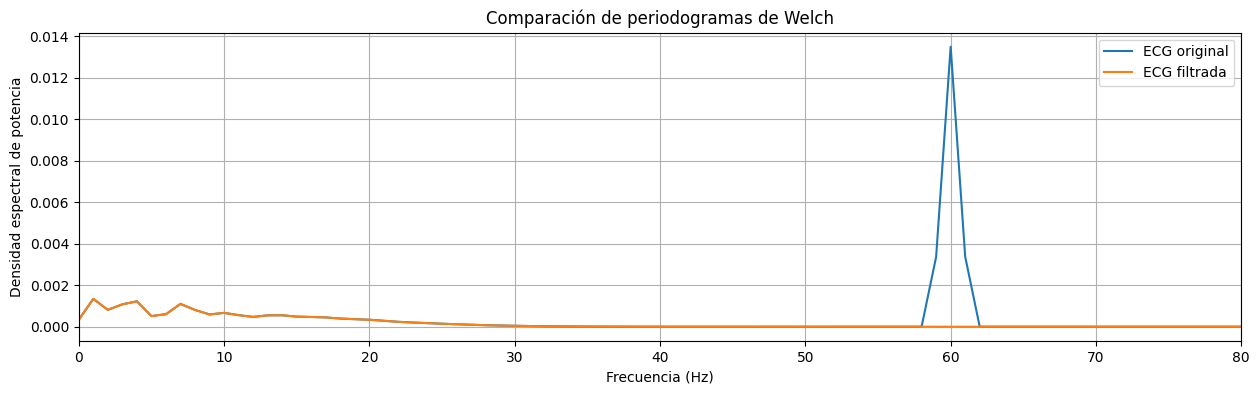

In [105]:
# Periodograma de Welch de la señal filtrada

f_filtrada, Pxx_filtrada = welch(
    ecg_filtrada,
    fs=Fs,
    window="hann",#Ventana de Hanning
    nperseg=nperseg,
    noverlap=noverlap
)

plt.figure(figsize=(15,4))
plt.plot(f, Pxx, label="ECG original")
plt.plot(f_filtrada, Pxx_filtrada, label="ECG filtrada")
plt.grid()
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia")
plt.title("Comparación de periodogramas de Welch")
plt.xlim(0, 80)
plt.legend()
plt.show()

En la comparación de los periodogramas de Welch se observa que la señal ECG original presenta un pico muy marcado alrededor de los 60 Hz, lo cual indica la presencia de una componente de ruido en esa frecuencia. Después del filtrado, dicho pico desaparece casi por completo, mientras que se conserva la mayor parte del contenido de baja frecuencia de la señal, donde se encuentra la información principal del ECG. Esto comprueba que el filtrado aplicado fue efectivo para reducir el ruido de 60 Hz sin eliminar las componentes más importantes de la señal cardíaca.

In [106]:
# Comprobación específica alrededor de 60 Hz

idx_60_original = np.argmin(np.abs(f - 60))
idx_60_filtrada = np.argmin(np.abs(f_filtrada - 60))

print("Potencia alrededor de 60 Hz antes del filtrado:", Pxx[idx_60_original])
print("Potencia alrededor de 60 Hz después del filtrado:", Pxx_filtrada[idx_60_filtrada])

Potencia alrededor de 60 Hz antes del filtrado: 0.013487629358508958
Potencia alrededor de 60 Hz después del filtrado: 2.9237513661893598e-08


La potencia alrededor de 60 Hz antes del filtrado fue de aproximadamente 1.35×10
−2
, mientras que después del filtrado disminuyó a aproximadamente 2.92×10
−8
. Esta reducción confirma que la componente de 60 Hz fue eliminada casi por completo. Por lo tanto, el filtrado aplicado fue efectivo para atenuar el ruido presente en esa frecuencia, conservando la señal ECG reconstruida mediante la transformada inversa de Fourier.

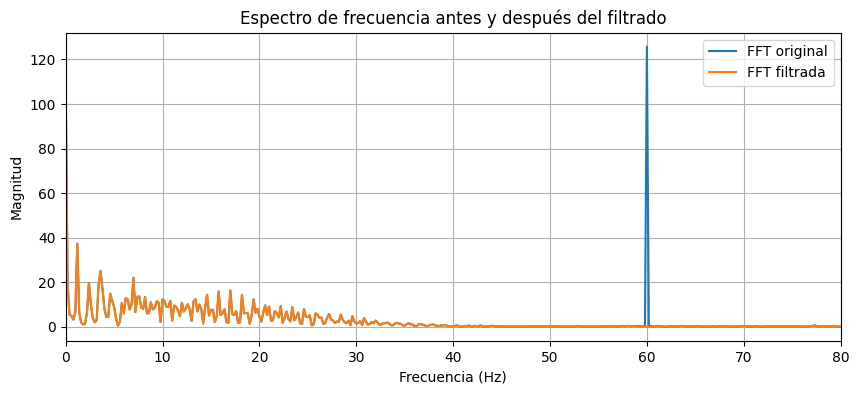

In [107]:
# Espectro de magnitud usando FFT antes y después del filtrado

F_pos = freq[:N//2]
X_original = np.abs(F_ecg[:N//2])
X_filtrada = np.abs(F_ecg_filtrada[:N//2])

plt.figure(figsize=(10,4))
plt.plot(F_pos, X_original, label="FFT original")
plt.plot(F_pos, X_filtrada, label="FFT filtrada")
plt.grid()
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.title("Espectro de frecuencia antes y después del filtrado")
plt.xlim(0, 80)
plt.legend()
plt.show()

En el espectro de frecuencia se observa que la señal ECG original presenta una componente dominante alrededor de los 60 Hz, evidenciada por un pico de gran magnitud. Esta componente no corresponde principalmente a la actividad cardíaca, sino a ruido de alta frecuencia, probablemente asociado a interferencia eléctrica. Después del filtrado, el pico en 60 Hz desaparece, mientras que las componentes de menor frecuencia se conservan. Esto confirma que el procedimiento de filtrado mediante FFT eliminó selectivamente la componente no deseada y permitió reconstruir la señal filtrada mediante la transformada inversa de Fourier.


Para el cálculo del periodograma de Welch se utilizó una ventana Hanning o Hann, definida en Python mediante window="hann". Esta ventana se usa para suavizar los bordes de cada segmento y reducir la fuga espectral durante el análisis frecuencial. Además, se seleccionó un solapamiento del 50%, ya que para una ventana Hann este valor representa un balance adecuado entre una buena estimación de la potencia y evitar contar excesivamente la misma información entre segmentos consecutivos [1].

En este caso, el ancho de ventana fue de 250 muestras. Como la frecuencia de muestreo de la señal ECG es \(F_s = 250\,Hz\), esta ventana corresponde a 1 segundo de señal. Esta duración permite tener una resolución frecuencial suficiente para identificar la componente de ruido alrededor de 60 Hz, sin perder completamente la variación temporal de la señal.

Después de identificar el componente de ruido, se aplicó un filtrado en el dominio de la frecuencia usando la FFT y luego se reconstruyó la señal mediante la transformada inversa de Fourier. La función ifft permite obtener la transformada inversa de la DFT calculada con fft, por lo que se utiliza para regresar la señal filtrada al dominio del tiempo [2].

**e) análisis de frecuencia para sano y con Parkinson**

Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja)

In [108]:
# Cargar archivos EEG

control_mat = loadmat("C012_EP_reposo_CONTROL.mat")
parkinson_mat = loadmat("P004_EP_reposo_PARKISON.mat")

print(control_mat.keys())
print(parkinson_mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data'])
dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [109]:
# Extraer los datos

eeg_control = control_mat["data"]
eeg_parkinson = parkinson_mat["data"]

print("Dimensiones EEG control:", eeg_control.shape)
print("Dimensiones EEG Parkinson:", eeg_parkinson.shape)
Fs_eeg = 160 #utilizamos esta frecuencia como referencia al proyecto 1 ya que no encontramos vector de tiempo en el archivo

Dimensiones EEG control: (8, 2000, 172)
Dimensiones EEG Parkinson: (8, 2000, 138)


Aunque en el Proyecto 1 se trabajó con un montaje de 64 canales, los archivos suministrados para esta práctica contienen 8 canales. Por esta razón, se seleccionó el canal 1 para realizar el análisis comparativo entre el paciente sano y el paciente con Parkinson, de acuerdo con la indicación de la guía de elegir un canal al azar en caso de no haber identificado previamente un canal con diferencias.

In [110]:
# Selección del canal
# Como los archivos EEG tienen 8 canales, elegimos el canal 1.
# En Python el canal 1 corresponde al índice 0.

canal = 0
canal_nombre = "Canal 1"

# Extraer señal del canal seleccionado
senal_control = eeg_control[canal]
senal_parkinson = eeg_parkinson[canal]

# Los datos tienen forma: muestras x épocas
# Por eso se promedian las épocas para obtener una sola señal representativa

senal_control_prom = np.mean(senal_control, axis=1)
senal_parkinson_prom = np.mean(senal_parkinson, axis=1)

print("Canal seleccionado:", canal_nombre)
print("Tamaño señal control:", senal_control_prom.shape)
print("Tamaño señal Parkinson:", senal_parkinson_prom.shape)

Canal seleccionado: Canal 1
Tamaño señal control: (2000,)
Tamaño señal Parkinson: (2000,)


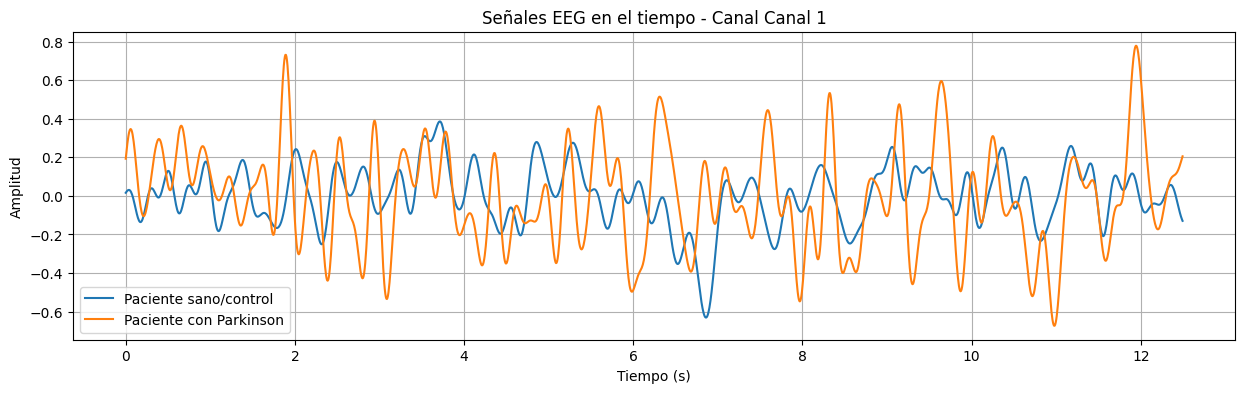

In [111]:
# Vector de tiempo

N_control = len(senal_control_prom)
N_parkinson = len(senal_parkinson_prom)

t_control = np.arange(N_control) / Fs_eeg
t_parkinson = np.arange(N_parkinson) / Fs_eeg

plt.figure(figsize=(15,4))
plt.plot(t_control, senal_control_prom, label="Paciente sano/control")
plt.plot(t_parkinson, senal_parkinson_prom, label="Paciente con Parkinson")
plt.grid()
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señales EEG en el tiempo - Canal " + canal_nombre)
plt.legend()
plt.show()

En la figura se observa la comparación temporal de las señales EEG promedio del paciente sano/control y del paciente con Parkinson para el canal 1. Ambas señales presentan oscilaciones variables en el tiempo, propias de registros EEG en reposo. Visualmente, la señal del paciente con Parkinson presenta mayores cambios de amplitud en algunos intervalos, especialmente entre 6 s y 12 s, mientras que la señal del paciente sano/control muestra una variación más moderada. Sin embargo, esta comparación en el dominio del tiempo no permite identificar con claridad en qué rangos de frecuencia se presentan las diferencias. Por esta razón, se realiza posteriormente el análisis mediante periodogramas de Welch, ya que este permite comparar la distribución de potencia de las señales en función de la frecuencia. Para interpretar los resultados se tendrán en cuenta las bandas típicas de EEG: delta, theta, alpha, beta y gamma [3].

In [112]:
# Parámetros de Welch

nperseg = Fs_eeg          # Ventana de 1 segundo = 160 muestras
noverlap = nperseg // 2   # Solapamiento del 50% = 80 muestras

print("Ancho de ventana:", nperseg, "muestras")
print("Solapamiento:", noverlap, "muestras")

Ancho de ventana: 160 muestras
Solapamiento: 80 muestras


Para este análisis se utilizó una ventana Hanning de 160 muestras. Dado que la frecuencia de muestreo del EEG es de 160 Hz, este ancho de ventana corresponde a 1 segundo de señal, lo que permite obtener una resolución frecuencial aproximada de 1 Hz. Además, se usó un solapamiento de 80 muestras, equivalente al 50% de la ventana. Esta elección permite aprovechar mejor la información entre segmentos consecutivos y obtener una estimación más estable del periodograma de Welch [2]. Las bandas de EEG se interpretan considerando los rangos comúnmente usados: delta, theta, alpha, beta y gamma [3].

In [113]:
# Periodograma de Welch

f_control, Pxx_control = welch(
    senal_control_prom,
    fs=Fs_eeg,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap
)

f_parkinson, Pxx_parkinson = welch(
    senal_parkinson_prom,
    fs=Fs_eeg,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap
)

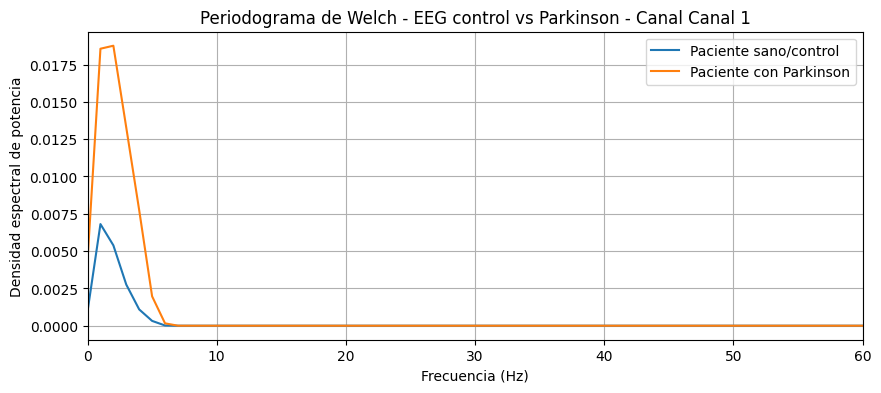

In [114]:
# Comparación de periodogramas

plt.figure(figsize=(10,4))
plt.plot(f_control, Pxx_control, label="Paciente sano/control")
plt.plot(f_parkinson, Pxx_parkinson, label="Paciente con Parkinson")
plt.grid()
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Densidad espectral de potencia")
plt.title("Periodograma de Welch - EEG control vs Parkinson - Canal " + canal_nombre)
plt.xlim(0, 60)
plt.legend()
plt.show()

En el periodograma de Welch se observa que ambas señales EEG concentran la mayor parte de su potencia en bajas frecuencias, principalmente por debajo de 5 Hz. Esto indica que, para el canal 1 seleccionado, la actividad dominante se encuentra en la banda delta y parte inicial de la banda theta. Al comparar ambos pacientes, la señal del paciente con Parkinson presenta una densidad espectral de potencia mayor que la del paciente sano/control en este rango de bajas frecuencias. Esto sugiere que, en el canal analizado, el paciente con Parkinson tiene mayor contribución de componentes lentas en la señal EEG. A partir de frecuencias superiores a aproximadamente 5 Hz, la potencia disminuye considerablemente en ambos casos, por lo que no se observan diferencias relevantes en bandas de mayor frecuencia como alpha, beta o gamma.

In [115]:
# Función para calcular potencia por banda

def potencia_banda(f, Pxx, fmin, fmax):
    indices = (f >= fmin) & (f <= fmax)
    return np.trapz(Pxx[indices], f[indices])

In [116]:
# Bandas EEG

bandas = {
    "Delta (0.5-4 Hz)": (0.5, 4),
    "Theta (4-8 Hz)": (4, 8),
    "Alpha (8-13 Hz)": (8, 13),
    "Beta (13-30 Hz)": (13, 30),
    "Gamma (30-45 Hz)": (30, 45)
}

potencias_control = {}
potencias_parkinson = {}

for nombre, (fmin, fmax) in bandas.items():
    potencias_control[nombre] = potencia_banda(f_control, Pxx_control, fmin, fmax)
    potencias_parkinson[nombre] = potencia_banda(f_parkinson, Pxx_parkinson, fmin, fmax)

print("Potencias por banda - Paciente sano/control")
for banda, potencia in potencias_control.items():
    print(banda, ":", potencia)

print("\nPotencias por banda - Paciente con Parkinson")
for banda, potencia in potencias_parkinson.items():
    print(banda, ":", potencia)

Potencias por banda - Paciente sano/control
Delta (0.5-4 Hz) : 0.012094254787628005
Theta (4-8 Hz) : 0.0008857005074356858
Alpha (8-13 Hz) : 3.617464914317918e-08
Beta (13-30 Hz) : 1.1370454670879454e-09
Gamma (30-45 Hz) : 1.0457391056049568e-11

Potencias por banda - Paciente con Parkinson
Delta (0.5-4 Hz) : 0.045185827362712205
Theta (4-8 Hz) : 0.006001143892415682
Alpha (8-13 Hz) : 1.697282503011351e-07
Beta (13-30 Hz) : 4.977078897515274e-09
Gamma (30-45 Hz) : 4.416932059277098e-11


/tmp/ipykernel_9024/1955849117.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[indices], f[indices])


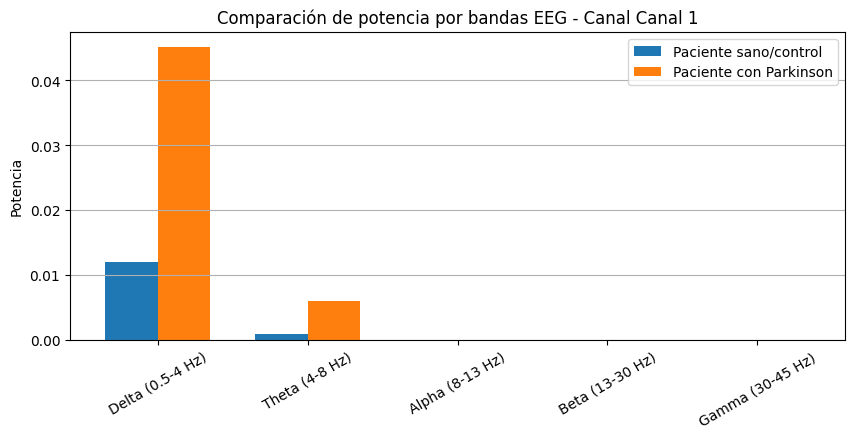

In [117]:
# Gráfica comparativa por bandas

nombres_bandas = list(bandas.keys())
valores_control = [potencias_control[b] for b in nombres_bandas]
valores_parkinson = [potencias_parkinson[b] for b in nombres_bandas]

x = np.arange(len(nombres_bandas))
ancho = 0.35

plt.figure(figsize=(10,4))
plt.bar(x - ancho/2, valores_control, ancho, label="Paciente sano/control")
plt.bar(x + ancho/2, valores_parkinson, ancho, label="Paciente con Parkinson")
plt.xticks(x, nombres_bandas, rotation=30)
plt.ylabel("Potencia")
plt.title("Comparación de potencia por bandas EEG - Canal " + canal_nombre)
plt.grid(axis="y")
plt.legend()
plt.show()

En la comparación de potencia por bandas EEG se observa que, para el canal 1, el paciente con Parkinson presenta mayor potencia que el paciente sano/control en todas las bandas analizadas. Sin embargo, la diferencia más marcada se encuentra en la banda delta 0.5−4Hz, donde la potencia del paciente con Parkinson fue aproximadamente 0.0452, mientras que en el paciente sano/control fue aproximadamente 0.0121. También se observa una diferencia en la banda theta 4−8Hz, aunque de menor magnitud.

Estos resultados coinciden con lo observado en el periodograma de Welch, donde la mayor parte de la energía de ambas señales se concentraba en bajas frecuencias. En este canal, el paciente con Parkinson presenta una mayor contribución de componentes lentas, principalmente en delta y theta. En cambio, las bandas alpha, beta y gamma presentan valores de potencia muy bajos en ambos casos, por lo que no se evidencian diferencias relevantes en frecuencias más altas. Las bandas fueron interpretadas de acuerdo con los rangos típicos usados en EEG: delta, theta, alpha, beta y gamma [3].

## Conclusiones

La práctica permitió comprender la importancia del análisis frecuencial en señales discretas y bioseñales. Se comprobó que una señal puede representarse en función del tiempo o del número de muestras, manteniendo los mismos valores cuando se aplica correctamente la relación de muestreo \(t=nT_s\) [1].

Mediante la FFT se identificaron las componentes frecuenciales de una señal formada por sinusoides de 40 Hz, 80 Hz y 160 Hz. Además, con la transformada inversa de Fourier se verificó que es posible reconstruir la señal original a partir de su representación en frecuencia [2].

El filtrado en frecuencia permitió eliminar componentes específicas de una señal, demostrando que al conservar o anular ciertos coeficientes de la FFT se modifica directamente la señal reconstruida en el dominio del tiempo.

En la señal ECG, el periodograma de Welch permitió detectar ruido alrededor de 60 Hz. Después del filtrado, la potencia en esta frecuencia disminuyó casi por completo, confirmando que el procedimiento fue efectivo para reducir la interferencia sin eliminar las características principales de la señal cardíaca.

En el análisis EEG, el paciente con Parkinson presentó mayor potencia en bajas frecuencias, especialmente en las bandas delta y theta, en comparación con el paciente sano/control. Por el contrario, las bandas alpha, beta y gamma presentaron valores muy bajos en ambos casos. Esto sugiere que, para el canal analizado, las diferencias más importantes se encuentran en las componentes lentas de la señal EEG [3].

## Referencias
[1] SciPy Developers. scipy.signal.welch. SciPy Documentation. Disponible en: documentación oficial de SciPy.

[2] NumPy Developers. numpy.fft.ifft. NumPy Documentation. Disponible en: documentación oficial de NumPy.

[3] A. Chaddad, Y. Wu, R. Kateb y A. Bouridane, “Electroencephalography Signal Processing: A Comprehensive Review and Analysis of Methods and Techniques,” Sensors, vol. 23, no. 14, 2023. Disponible en: https://pmc.ncbi.nlm.nih.gov/articles/PMC10385593/